# FixtureIQ — Full Data Exploration: All Sources (2022-23 to 2024-25)

## Objectives
1. Inventory every data source available in the project
2. Check missing values, data quality, schema compatibility
3. Understand name matching (SofaScore vs FBref vs Injury)
4. Assess cross-source merge feasibility
5. Build a unified view of what data is usable

## Seasons Covered: 2022-23, 2023-24, 2024-25

## Data Sources
- **SofaScore Dynamic** (`Data/<season>/sofascore_dynamic/`) — per-match player stats + workload features
- **FBref per-match** (`Data/<season>/fbref/`) — per-match player reports for UCL teams
- **SofaScore season aggregates** (`Data/<season>/sofascore/`) — season-level player stats
- **Injuries** (`Data/<season>/injuries/`) — injury records for all PL teams
- **Club Elo** (`Data/clubelo_understat/fixtureiq_elo_master.csv`) — team strength ratings
- **Understat** (`Data/clubelo_understat/fixtureiq_understat_master.csv`) — xG match data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, re
from pathlib import Path
from collections import defaultdict
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

BASE = Path('..')
print(f'Project root: {BASE.resolve()}')
print(f'Data exists: {(BASE / "Data").exists()}')

Project root: C:\Users\ItxaroAizpuruaArcona\Desktop\S_A\Fixture-IQ-playground
Data exists: True


---
## 1. SofaScore Dynamic Data (the primary workload dataset)

These are per-match player records with pre-engineered workload features: `rest_days`, `acwr_ratio`, `high_congestion_flag`, `min_last_7d`, etc.

In [2]:
def explore_sofascore_dynamic(season_code):
    """Load and explore the SofaScore Dynamic clean dataset for a given season."""
    path = BASE / 'Data' / season_code / 'sofascore_dynamic' / 'fixtureiq_dynamic_analytics_clean.csv'
    master_path = BASE / 'Data' / season_code / 'sofascore_dynamic' / 'fixtureiq_dynamic_master.csv'
    
    if not path.exists():
        print(f'[WARN] {season_code}: clean file not found')
        return None, None
    
    df = pd.read_csv(path)
    df_master = pd.read_csv(master_path) if master_path.exists() else None
    
    print(f'=== {season_code} SofaScore Dynamic ===')
    print(f'Clean: {df.shape[0]:,} rows x {df.shape[1]} cols')
    if df_master is not None:
        print(f'Master: {df_master.shape[0]:,} rows x {df_master.shape[1]} cols')
    
    # Date range
    date_col = 'match_date_str' if 'match_date_str' in df.columns else 'date'
    print(f'Date range: {df[date_col].min()} to {df[date_col].max()}')
    
    # Missing values
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f'\nMissing values:')
        for c, v in nulls.items():
            print(f'  {c}: {v:>6} ({v/df.shape[0]*100:5.1f}%)')
    else:
        print('\nMissing values: (none)')
    
    # Teams & players
    print(f'\nUnique teams: {df["teamName"].nunique()}')
    print(f'Unique players: {df["name"].nunique()}')
    
    # Player minutes distribution
    if 'minutesPlayed' in df.columns:
        no_min = (df['minutesPlayed'] == 0).sum()
        low_min = ((df['minutesPlayed'] > 0) & (df['minutesPlayed'] <= 45)).sum()
        print(f'\nMinutes distribution:')
        print(f'  0 min (unused sub): {no_min:>6} ({no_min/df.shape[0]*100:5.1f}%)')
        print(f'  1-45 min (sub):     {low_min:>6} ({low_min/df.shape[0]*100:5.1f}%)')
    
    return df, df_master

sofascore_dynamic = {}
for s in ['2022-2023', '2023-2024', '2024-2025']:
    df, dfm = explore_sofascore_dynamic(s)
    if df is not None:
        sofascore_dynamic[s] = df

=== 2022-2023 SofaScore Dynamic ===
Clean: 6,500 rows x 19 cols
Master: 7,304 rows x 108 cols
Date range: 2022-08-06 to 2023-06-10

Missing values:
  rating:   1616 ( 24.9%)
  elo:    707 ( 10.9%)
  team_xg:   6500 (100.0%)
  team_xga:   6500 (100.0%)
  xg_difference:   6500 (100.0%)

Unique teams: 36
Unique players: 900

Minutes distribution:
  0 min (unused sub):   1488 ( 22.9%)
  1-45 min (sub):       1515 ( 23.3%)
=== 2023-2024 SofaScore Dynamic ===
Clean: 13,142 rows x 17 cols
Master: 14,758 rows x 106 cols
Date range: 2023-08-11 to 2024-04-25

Missing values:
  rating:   3130 ( 23.8%)

Unique teams: 34
Unique players: 938

Minutes distribution:
  0 min (unused sub):   2910 ( 22.1%)
  1-45 min (sub):       3123 ( 23.8%)
=== 2024-2025 SofaScore Dynamic ===
Clean: 6,726 rows x 19 cols
Master: 7,587 rows x 117 cols
Date range: 2024-08-17 to 2025-05-25

Missing values:
  rating:   1592 ( 23.7%)
  elo:    678 ( 10.1%)
  team_xg:   6726 (100.0%)
  team_xga:   6726 (100.0%)
  xg_differen

### 1.1 Missing Value Root-Cause Analysis

Let's understand WHY rating, ELO, and xG are missing.

In [3]:
# Rating nulls: are they players with 0 minutes?
for s, df in sofascore_dynamic.items():
    null_rating = df['rating'].isna()
    if null_rating.any():
        zero_min_null = ((df['minutesPlayed'] == 0) & null_rating).sum()
        print(f'{s}: null rating where min==0: {zero_min_null}/{null_rating.sum()} ({zero_min_null/null_rating.sum()*100:.1f}%)')
        # Sample of non-zero min with null rating
        non_zero_null = df[null_rating & (df['minutesPlayed'] > 0)]
        if len(non_zero_null) > 0:
            print(f'  Non-zero min with null rating: {len(non_zero_null)} rows')
            print(f'  Sample: {non_zero_null[["name","teamName","minutesPlayed","match_date_str"]].head(3).to_string(index=False)}')

2022-2023: null rating where min==0: 1488/1616 (92.1%)
  Non-zero min with null rating: 128 rows
  Sample:                    name               teamName  minutesPlayed match_date_str
           Aaron Hickey              Brentford              1     2023-04-26
           Adam Webster Brighton & Hove Albion              1     2023-01-14
Alex Oxlade-Chamberlain           Liverpool FC              1     2022-11-06
2023-2024: null rating where min==0: 2910/3130 (93.0%)
  Non-zero min with null rating: 220 rows
  Sample:              name          teamName  minutesPlayed match_date_str
  Aaron Cresswell   West Ham United              1     2023-11-12
     Aaron Ramsey           Burnley              1     2023-12-26
Aaron Wan-Bissaka Manchester United              5     2023-09-16
2024-2025: null rating where min==0: 1478/1592 (92.8%)
  Non-zero min with null rating: 114 rows
  Sample:                  name       teamName  minutesPlayed match_date_str
Abdul Fatawu Issahaku Leicester City    

In [4]:
# ELO nulls: which teams?
for s, df in sofascore_dynamic.items():
    if 'elo' not in df.columns:
        print(f'{s}: elo column missing entirely')
        continue
    null_elo = df['elo'].isna()
    if null_elo.any():
        teams_null = df.loc[null_elo, 'teamName'].value_counts()
        print(f'{s}: elo null for teams:')
        for t, c in teams_null.items():
            print(f'  {t}: {c} rows')

2022-2023: elo null for teams:
  Leeds United: 144 rows
  Nottingham Forest: 144 rows
  Borussia Dortmund: 78 rows
  SSC Napoli: 41 rows
  GNK Dinamo Zagreb: 41 rows
  FC Bayern München: 40 rows
  AFC Ajax: 39 rows
  Sporting CP: 38 rows
  Red Bull Salzburg: 37 rows
  FC København: 36 rows
  Eintracht Frankfurt: 35 rows
  Olympique de Marseille: 34 rows
2023-2024: elo column missing entirely
2024-2025: elo null for teams:
  Paris Saint-Germain: 152 rows
  Nottingham Forest: 144 rows
  Club Brugge KV: 76 rows
  PSV Eindhoven: 54 rows
  Girona FC: 40 rows
  Sporting CP: 39 rows
  AS Monaco: 38 rows
  Shakhtar Donetsk: 21 rows
  BSC Young Boys: 20 rows
  AC Sparta Praha: 20 rows
  ŠK Slovan Bratislava: 20 rows
  GNK Dinamo Zagreb: 20 rows
  FC Bayern München: 18 rows
  Bayer 04 Leverkusen: 16 rows


In [4]:
# xG nulls: why are team_xg, team_xga, xg_difference 100% null in clean files?
# Check the master file for xG columns
for s in ['2022-2023', '2023-2024', '2024-2025']:
    master_path = BASE / 'Data' / s / 'sofascore_dynamic' / 'fixtureiq_dynamic_master.csv'
    if master_path.exists():
        dfm = pd.read_csv(master_path, nrows=5)
        xg_cols = [c for c in dfm.columns if 'xg' in c.lower() or 'xG' in c]
        print(f'{s} master xG columns: {xg_cols}')
        if 'home_xg' in dfm.columns:
            null_hxg = pd.read_csv(master_path, usecols=['home_xg']).isna().sum().iloc[0]
            total = pd.read_csv(master_path, usecols=['home_xg']).shape[0]
            print(f'  home_xg nulls: {null_hxg}/{total} ({null_hxg/total*100:.1f}%)')

2022-2023 master xG columns: ['home_xg', 'away_xg', 'team_xg', 'team_xga', 'xg_difference']
  home_xg nulls: 7304/7304 (100.0%)
2023-2024 master xG columns: []
2024-2025 master xG columns: ['home_xg', 'away_xg', 'team_xg', 'team_xga', 'xg_difference']
  home_xg nulls: 7587/7587 (100.0%)


### 1.2 Workload Feature Distributions

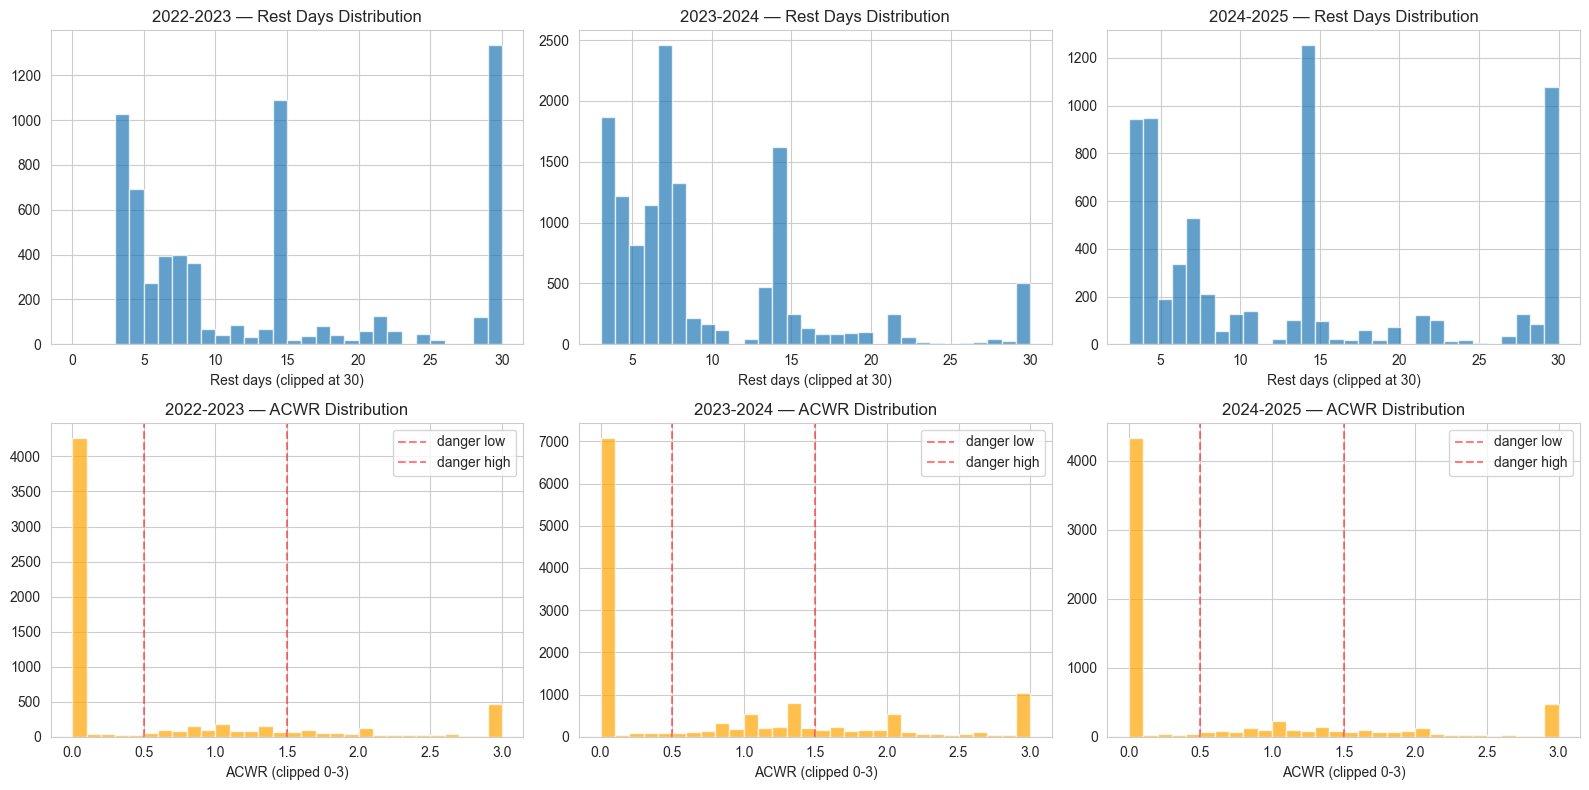

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for idx, (s, df) in enumerate(sofascore_dynamic.items()):
    ax = axes[0, idx]
    if 'rest_days' in df.columns:
        df['rest_days'].clip(0, 30).hist(bins=30, ax=ax, alpha=0.7)
        ax.set_title(f'{s} — Rest Days Distribution')
        ax.set_xlabel('Rest days (clipped at 30)')
    
    ax2 = axes[1, idx]
    if 'acwr_ratio' in df.columns:
        df['acwr_ratio'].clip(0, 3).hist(bins=30, ax=ax2, alpha=0.7, color='orange')
        ax2.axvline(0.5, color='red', ls='--', alpha=0.5, label='danger low')
        ax2.axvline(1.5, color='red', ls='--', alpha=0.5, label='danger high')
        ax2.set_title(f'{s} — ACWR Distribution')
        ax2.set_xlabel('ACWR (clipped 0-3)')
        ax2.legend()

plt.tight_layout()
plt.savefig('../results/data_exploration_workload_dist.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Congestion flag rates across seasons
print('High Congestion (<=3 days rest) rates:')
for s, df in sofascore_dynamic.items():
    if 'high_congestion_flag' in df.columns:
        rate = df['high_congestion_flag'].mean() * 100
        print(f'  {s}: {rate:.1f}% of matches ({df["high_congestion_flag"].sum():,} of {df.shape[0]:,})')

High Congestion (<=3 days rest) rates:
  2022-2023: 15.8% of matches (1,030 of 6,500)
  2023-2024: 14.2% of matches (1,866 of 13,142)
  2024-2025: 14.0% of matches (943 of 6,726)


---
## 2. FBref Per-Match Data

FBref covers specific UCL-participant PL teams per season. Let's check what's available.

In [9]:
# Section 2 - FBref Data Exploration
def explore_fbref_season_new(season_code):
    """Explore FBref data using the newly consolidated master files."""
    base = BASE / 'Data' / season_code / 'fbref'
    if not base.exists():
        print(f'{season_code}: no FBref directory')
        return {}
    
    teams = {}
    for team_dir in sorted(base.iterdir()):
        if not team_dir.is_dir():
            continue
            
        # Target the new consolidated files
        master_ps = team_dir / 'match_reports' / 'master_player_stats.csv'
        master_gk = team_dir / 'match_reports' / 'master_goalkeeper_stats.csv'
        master_lu = team_dir / 'match_reports' / 'master_lineups.csv'
        
        teams[team_dir.name] = {
            'has_player_stats': master_ps.exists(),
            'has_gk_stats': master_gk.exists(),
            'has_lineups': master_lu.exists(),
            'player_stats_rows': pd.read_csv(master_ps).shape[0] if master_ps.exists() else 0
        }
    return teams

for s in ['2022-2023', '2023-2024', '2024-2025']:
    teams = explore_fbref_season_new(s)
    if teams:
        print(f'=== {s} FBref (Consolidated Structure) ===')
        for t, info in teams.items():
            print(f'  {t}: Stats={info["player_stats_rows"]} rows | GK={info["has_gk_stats"]} | Lineups={info["has_lineups"]}')
    print("\n")

=== 2022-2023 FBref (Consolidated Structure) ===
  chelsea_2022_2023: Stats=778 rows | GK=True | Lineups=True
  liverpool_2022_2023: Stats=805 rows | GK=True | Lineups=True
  manchester_city_2022_2023: Stats=872 rows | GK=True | Lineups=True
  tottenham_hotspur_2022_2023: Stats=732 rows | GK=True | Lineups=True


=== 2023-2024 FBref (Consolidated Structure) ===
  arsenal_2023_2024: Stats=769 rows | GK=True | Lineups=True
  manchester_city_2023_2024: Stats=805 rows | GK=True | Lineups=True
  manchester_united_2023_2024: Stats=783 rows | GK=True | Lineups=True
  newcastle_united_2023_2024: Stats=759 rows | GK=True | Lineups=True


=== 2024-2025 FBref (Consolidated Structure) ===
  arsenal_2024_2025: Stats=866 rows | GK=True | Lineups=True
  aston_villa_2024_2025: Stats=880 rows | GK=True | Lineups=True
  liverpool_2024_2025: Stats=861 rows | GK=True | Lineups=True
  manchester_city_2024_2025: Stats=829 rows | GK=True | Lineups=True




In [10]:
# Sample FBref match report columns & completeness
import glob
fbref_samples = {}
for s in ['2022-2023', '2023-2024', '2024-2025']:
    base = BASE / 'Data' / s / 'fbref'
    if not base.exists():
        continue
    for team_dir in sorted(base.iterdir()):
        if not team_dir.is_dir():
            continue
        mr_dir = team_dir / 'match_reports'
        if not mr_dir.exists():
            continue
        # Find first match report
        matches = sorted(mr_dir.iterdir())
        if not matches:
            continue
        for m in matches[:1]:  # just first match
            ps_file = m / f'{m.name}_player_stats.csv'
            if ps_file.exists():
                df = pd.read_csv(ps_file)
                fbref_samples[f'{s}/{team_dir.name}'] = {
                    'rows': df.shape[0],
                    'cols': df.shape[1],
                    'col_names': list(df.columns),
                    'sample': df.head(2).to_dict('records'),
                    'nulls': df.isnull().sum()[df.isnull().sum() > 0].to_dict()
                }
                break

for k, v in list(fbref_samples.items())[:3]:
    print(f'\n=== {k} ===')
    print(f'Shape: {v["rows"]} x {v["cols"]}')
    print(f'Columns: {v["col_names"]}')
    if v['nulls']:
        print(f'Nulls: {v["nulls"]}')


=== 2022-2023/chelsea_2022_2023 ===
Shape: 16 x 33
Columns: ['Match_ID', 'Match_Report_URL', 'Date', 'Competition', 'Round', 'Venue', 'Opponent', 'Result', 'Match_Report_Name', 'Team', 'Player', 'shirtnumber', 'Nation', 'Pos', 'Age', 'Min', 'Gls', 'Ast', 'PK', 'PKatt', 'shots', 'shots_on_target', 'CrdY', 'CrdR', 'fouls', 'fouled', 'offsides', 'crosses', 'tackles_won', 'interceptions', 'own_goals', 'pens_won', 'pens_conceded']
Nulls: {'pens_won': 16, 'pens_conceded': 16}

=== 2022-2023/liverpool_2022_2023 ===
Shape: 17 x 33
Columns: ['Match_ID', 'Match_Report_URL', 'Date', 'Competition', 'Round', 'Venue', 'Opponent', 'Result', 'Match_Report_Name', 'Team', 'Player', 'shirtnumber', 'Nation', 'Pos', 'Age', 'Min', 'Gls', 'Ast', 'PK', 'PKatt', 'shots', 'shots_on_target', 'CrdY', 'CrdR', 'fouls', 'fouled', 'offsides', 'crosses', 'tackles_won', 'interceptions', 'own_goals', 'pens_won', 'pens_conceded']
Nulls: {'own_goals': 17, 'pens_won': 17, 'pens_conceded': 17}

=== 2022-2023/manchester_cit

### 2.1 FBref Data Completeness

Let's verify that the `load_fbref_data()` function in the training pipeline correctly loads all available FBref data.

In [10]:
# Simulate what the training pipeline loads
def load_fbref_simulated():
    """Replicate the load_fbref_data logic from train_fatigue_model.py"""
    all_rows = []
    for season_str in ['2022-2023', '2023-2024', '2024-2025']:
        season_path = BASE / 'Data' / season_str / 'fbref'
        if season_path.exists():
            for team_dir in sorted(season_path.iterdir()):
                if not team_dir.is_dir():
                    continue
                mr_dir = team_dir / 'match_reports'
                if not mr_dir.exists():
                    continue
                for match_folder in sorted(mr_dir.iterdir()):
                    if not match_folder.is_dir():
                        continue
                    ps_file = match_folder / f'{match_folder.name}_player_stats.csv'
                    if ps_file.exists():
                        all_rows.append({'season': season_str, 'team_dir': team_dir.name, 'match': match_folder.name, 'file': str(ps_file)})
    return pd.DataFrame(all_rows)

fbref_inventory = load_fbref_simulated()
print(f'FBref total match reports found: {fbref_inventory.shape[0]}')
print(f'\nBreakdown by season:')
print(fbref_inventory.groupby('season')['match'].count().to_string())
print(f'\nBreakdown by team:')
print(fbref_inventory.groupby('team_dir')['match'].count().to_string())

FBref total match reports found: 652

Breakdown by season:
season
2022-2023    213
2023-2024    211
2024-2025    228

Breakdown by team:
team_dir
arsenal_2023_2024              51
arsenal_2024_2025              58
aston_villa_2024_2025          57
chelsea_2022_2023              50
liverpool_2022_2023            52
liverpool_2024_2025            56
manchester_city_2022_2023      61
manchester_city_2023_2024      57
manchester_city_2024_2025      57
manchester_united_2023_2024    52
newcastle_united_2023_2024     51
tottenham_hotspur_2022_2023    50


---
## 3. SofaScore Season Aggregate Data

These are season-level player aggregate stats with 115+ columns (all passing, defending, shooting, rating stats).

In [ ]:
# REVISED CELL: Section 3 - SofaScore Premier League Aggregates
import glob

def explore_sofascore_premier_league_aggregates():
    """Check SofaScore premier_league all_players files available under the new pathing rules."""
    # Strict routing to premier_league subdirectory
    pattern = str(BASE / 'Data' / '*' / 'sofascore' / 'premier_league' / '*_all_players.csv')
    files = sorted(glob.glob(pattern))
    
    print(f'Found {len(files)} Premier League aggregate player files:')
    info = []
    for f in files:
        df = pd.read_csv(f)
        parts = Path(f).relative_to(BASE).parts
        season = parts[1]
        comp = parts[3]  # Will explicitly be 'premier_league'
        
        info.append({'file': f, 'season': season, 'comp': comp, 'players': df.shape[0], 'cols': df.shape[1]})
        print(f'  {season}/{comp}: {df.shape[0]:>4} players, {df.shape[1]:>3} cols')
    return pd.DataFrame(info)

ss_agg = explore_sofascore_premier_league_aggregates()

Found 10 aggregate player files:


  2020-2021/champions_league:  735 players, 115 cols
  2020-2021/premier_league:  524 players, 115 cols


  2021-2022/champions_league:  747 players, 115 cols
  2021-2022/premier_league:  538 players, 115 cols
  2022-2023/champions_league:  722 players, 115 cols
  2022-2023/premier_league:  554 players, 115 cols
  2023-2024/champions_league:  724 players, 115 cols
  2023-2024/premier_league:  570 players, 115 cols
  2024-2025/champions_league:  879 players, 115 cols
  2024-2025/premier_league:  562 players, 115 cols


In [12]:
# Check SofaScore aggregate nulls
f = ss_agg.iloc[0]['file']
df = pd.read_csv(f)
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print(f'Nulls in {Path(f).name} ({df.shape[0]} players):')
if len(nulls) > 0:
    for c, v in nulls.items():
        print(f'  {c}: {v} ({v/df.shape[0]*100:.1f}%)')
else:
    print('  (none)')

Nulls in champions_league_2020_2021_all_players.csv (735 players):
  expectedAssists: 735 (100.0%)
  expectedGoals: 735 (100.0%)
  goalsPrevented: 735 (100.0%)
  outfielderBlocks: 735 (100.0%)


---
## 4. Injury Data

The ground-truth target variable. Let's check coverage and quality.

In [13]:
def explore_injuries():
    """Load and summarize injury data across all seasons."""
    all_inj = []
    for s in ['2022-2023', '2023-2024', '2024-2025']:
        inj_dir = BASE / 'Data' / s / 'injuries'
        if not inj_dir.exists():
            continue
        for f in sorted(inj_dir.iterdir()):
            if f.name.endswith('_injuries_days_out.csv'):
                df = pd.read_csv(f)
                df['season'] = s
                all_inj.append(df)
    
    if not all_inj:
        return pd.DataFrame()
    
    inj = pd.concat(all_inj, ignore_index=True)
    inj['fixture_date'] = pd.to_datetime(inj['fixture_date'], errors='coerce')
    inj['end_date'] = pd.to_datetime(inj['end_date'], errors='coerce')
    inj['days_out'] = pd.to_numeric(inj['days_out'], errors='coerce')
    
    return inj

injuries = explore_injuries()
print(f'Total injury records: {injuries.shape[0]:,}')
print(f'\nBy season:')
print(injuries.groupby('season').agg({'player_id': 'count', 'player_name': 'nunique', 'team_name': 'nunique'}).to_string())
print(f'\nDate range: {injuries["fixture_date"].min()} to {injuries["fixture_date"].max()}')
print(f'\nInjury types:')
print(injuries['injury_type'].value_counts().to_string())
print(f'\nDays out stats:')
print(injuries['days_out'].describe().to_string())

Total injury records: 9,526

By season:
           player_id  player_name  team_name
season                                      
2022-2023       2773          344         20
2023-2024       3600          404         20
2024-2025       3153          394         20

Date range: 2022-08-05 00:00:00 to 2025-05-25 00:00:00

Injury types:
injury_type
Missing Fixture    9296
Questionable        230

Days out stats:
count    9526.000000
mean      154.097208
std        92.302830
min         0.000000
25%        74.000000
50%       160.000000
75%       233.000000
max       307.000000


In [14]:
# Genuine vs non-injury breakdown
GENUINE = {
    "Abdominal strain", "Achilles Tendon Injury", "Ankle Injury", "Arm Injury",
    "Back Injury", "Broken Leg", "Calf Injury", "Concussion", "Eye injury",
    "Face Injury", "Finger Injury", "Foot Injury", "Groin Injury",
    "Hamstring Injury", "Hand Injury", "Head Injury", "Heel Injury",
    "Hip Injury", "Illness", "Injury", "Knee Injury", "Knock",
    "Leg Injury", "Lower Back Injury", "Muscle Injury", "Pelvis Injury",
    "Shoulder Injury", "Thigh Injury", "Toe Injury", "Wrist Injury",
}
NON_INJURY = {
    "Inactive", "Suspended", "Red Card", "Yellow Cards",
    "Coach's decision", "Loan agreement", "Personal Reasons",
    "Rest", "Health problems", "Convalescence", "Lacking Match Fitness",
}

injuries['is_injury'] = injuries['reason'].isin(GENUINE)
injuries['is_non_injury'] = injuries['reason'].isin(NON_INJURY)

print(f'Genuine injuries: {injuries["is_injury"].sum():,} ({injuries["is_injury"].mean()*100:.1f}%)')
print(f'Non-injury (suspension/rest/etc): {injuries["is_non_injury"].sum():,} ({injuries["is_non_injury"].mean()*100:.1f}%)')
print(f'Unclassified: {(~injuries["is_injury"] & ~injuries["is_non_injury"]).sum():,}')

print(f'\nTop 15 reasons:')
print(injuries['reason'].value_counts().head(15).to_string())

Genuine injuries: 8,360 (87.8%)
Non-injury (suspension/rest/etc): 945 (9.9%)
Unclassified: 221

Top 15 reasons:
reason
Knee Injury               2232
Thigh Injury              1421
Muscle Injury              924
Ankle Injury               908
Injury                     653
Calf Injury                524
Hamstring Injury           232
Red Card                   218
Groin Injury               206
Knock                      169
Suspended                  160
Inactive                   158
Shoulder Injury            156
Achilles Tendon Injury     152
Yellow Cards               139


In [15]:
# Teams covered by injury data
print('Teams per season:')
for s in ['2022-2023', '2023-2024', '2024-2025']:
    subset = injuries[injuries['season'] == s]
    teams = sorted(subset['team_name'].unique())
    print(f'  {s}: {len(teams)} teams -> {teams}')

Teams per season:
  2022-2023: 20 teams -> ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Leicester', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle', 'Nottingham Forest', 'Southampton', 'Tottenham', 'West Ham', 'Wolves']
  2023-2024: 20 teams -> ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Liverpool', 'Luton', 'Manchester City', 'Manchester United', 'Newcastle', 'Nottingham Forest', 'Sheffield Utd', 'Tottenham', 'West Ham', 'Wolves']
  2024-2025: 20 teams -> ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leicester', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle', 'Nottingham Forest', 'Southampton', 'Tottenham', 'West Ham', 'Wolves']


---
## 5. Context Data: Club Elo & Understat

These enrich the match data with team strength and expected goals.

In [16]:
# Club Elo
elo = pd.read_csv(BASE / 'Data' / 'clubelo_understat' / 'fixtureiq_elo_master.csv')
print(f'ClubElo: {elo.shape[0]} entries, {elo["team"].nunique()} unique teams')
print(f'Date range: {elo["from"].min()} to {elo["to"].max()}')
print(f'\nPL teams in Elo:')
pl_teams = ['Arsenal','Aston Villa','Bournemouth','Brentford','Brighton','Chelsea','Crystal Palace',
            'Everton','Fulham','Ipswich','Leicester','Liverpool','Man City','Man United',
            'Newcastle','Nottingham Forest','Southampton','Tottenham','West Ham','Wolves']
for t in pl_teams:
    found = elo[elo['team'] == t].shape[0]
    if found == 0:
        # try variations
        for alt in [t+' FC', t.replace(' ',''), t.replace(' ','_')]:
            found = elo[elo['team'] == alt].shape[0]
            if found > 0:
                print(f'  {t} -> found as "{alt}" ({found} entries)')
                break
        else:
            print(f'  {t}: NOT FOUND in Elo')

ClubElo: 630 entries, 630 unique teams
Date range: 2026-01-01 to 2026-05-30

PL teams in Elo:
  Nottingham Forest: NOT FOUND in Elo


In [17]:
# Understat
un = pd.read_csv(BASE / 'Data' / 'clubelo_understat' / 'fixtureiq_understat_master.csv')
print(f'Understat: {un.shape[0]} matches, seasons={sorted(un["season"].unique())}')
print(f'Date range: {un["date"].min()} to {un["date"].max()}')
print(f'\nTeam name examples:')
print(f'  Home teams: {sorted(un["home_team"].unique())[:15]}')
print(f'  Away teams: {sorted(un["away_team"].unique())[:15]}')

Understat: 1520 matches, seasons=[np.int64(2021), np.int64(2122), np.int64(2223), np.int64(2324)]


Date range: 2020-09-12 11:30:00 to 2024-05-19 15:00:00

Team name examples:
  Home teams: ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Manchester City']
  Away teams: ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Manchester City']


In [18]:
# Check why Understat xG fails to merge: name mismatch
# The dynamic pipeline uses TEAM_NAME_MAP but let's verify
TEAM_NAME_MAP = {
    'Arsenal': 'Arsenal', 'Aston Villa': 'Aston Villa',
    'Liverpool FC': 'Liverpool', 'Manchester City': 'Manchester City',
    'Manchester United': 'Manchester United', 'Newcastle United': 'Newcastle United',
    'Chelsea': 'Chelsea', 'Tottenham Hotspur': 'Tottenham Hotspur',
    'Tottenham': 'Tottenham Hotspur', 'Liverpool': 'Liverpool',
    'Brighton & Hove Albion': 'Brighton', 'Brighton': 'Brighton',
    'West Ham United': 'West Ham United', 'West Ham': 'West Ham United',
    'Wolverhampton': 'Wolverhampton', 'Wolves': 'Wolverhampton',
    'Leicester City': 'Leicester City', 'Leicester': 'Leicester City',
    'Ipswich Town': 'Ipswich Town', 'Southampton': 'Southampton',
    'Bournemouth': 'Bournemouth', 'Brentford': 'Brentford',
    'Crystal Palace': 'Crystal Palace', 'Everton': 'Everton',
    'Fulham': 'Fulham', 'Nottingham Forest': 'Nottingham Forest',
    "Nott'ham Forest": 'Nottingham Forest',
}

# Check: Understat team names that DON'T have a reverse mapping
dyn_team = 'Liverpool FC'
canon = TEAM_NAME_MAP.get(dyn_team, dyn_team)
print(f'Dynamic "{dyn_team}" -> canonical "{canon}"')
print(f'Understat has "{canon}": {"Liverpool" in un["home_team"].values}')
print()

# Check all dynamic PL teams vs Understat names
dyn = sofascore_dynamic['2022-2023']
dyn_teams = set(dyn['teamName'].unique())
un_teams = set(un['home_team'].unique()) | set(un['away_team'].unique())
print('Dynamic teams lacking Understat match:')
for t in sorted(dyn_teams):
    canon = TEAM_NAME_MAP.get(t, t)
    if canon not in un_teams and t not in un_teams:
        print(f'  {t} -> canon={canon} (Understat has: {[x for x in un_teams if x.lower()[:4]==canon.lower()[:4]]})')

Dynamic "Liverpool FC" -> canonical "Liverpool"


Understat has "Liverpool": True

Dynamic teams lacking Understat match:
  AFC Ajax -> canon=AFC Ajax (Understat has: [])
  Borussia Dortmund -> canon=Borussia Dortmund (Understat has: [])
  Eintracht Frankfurt -> canon=Eintracht Frankfurt (Understat has: [])
  FC Bayern München -> canon=FC Bayern München (Understat has: [])
  FC København -> canon=FC København (Understat has: [])
  GNK Dinamo Zagreb -> canon=GNK Dinamo Zagreb (Understat has: [])
  Inter -> canon=Inter (Understat has: [])
  Leeds United -> canon=Leeds United (Understat has: ['Leeds'])
  Leicester City -> canon=Leicester City (Understat has: ['Leicester'])
  Milan -> canon=Milan (Understat has: [])
  Olympique de Marseille -> canon=Olympique de Marseille (Understat has: [])
  RB Leipzig -> canon=RB Leipzig (Understat has: [])
  Rangers -> canon=Rangers (Understat has: [])
  Real Madrid -> canon=Real Madrid (Understat has: [])
  Red Bull Salzburg -> canon=Red Bull Salzburg (Understat has: [])
  SSC Napoli -> canon=SSC Na

---
## 6. Name Matching Across Sources

A critical issue: merging across SofaScore, FBref, and Injury data requires aligning player names.

In [19]:
# Compare player name formats across sources
dyn_players = set()
for s, df in sofascore_dynamic.items():
    if 'name' in df.columns:
        dyn_players.update(df['name'].unique())

# FBref names from match reports
fbref_players = set()
for s in ['2022-2023', '2023-2024', '2024-2025']:
    base = BASE / 'Data' / s / 'fbref'
    if not base.exists():
        continue
    for team_dir in base.iterdir():
        if not team_dir.is_dir():
            continue
        mr_dir = team_dir / 'match_reports'
        if not mr_dir.exists():
            continue
        for match_folder in mr_dir.iterdir():
            if not match_folder.is_dir():
                continue
            ps_file = match_folder / f'{match_folder.name}_player_stats.csv'
            if ps_file.exists():
                df = pd.read_csv(ps_file)
                if 'Player' in df.columns:
                    fbref_players.update(df['Player'].unique())

# Injury names
injury_players = set(injuries['player_name'].unique())

print(f'SofaScore Dynamic players: {len(dyn_players):,}')
print(f'FBref players: {len(fbref_players):,}')
print(f'Injury players: {len(injury_players):,}')
print()

# Show some examples of each format
print('5 SofaScore names:')
for n in sorted(dyn_players)[:5]:
    print(f'  "{n}"')
print('\n5 FBref names:')
for n in sorted(fbref_players)[:5]:
    print(f'  "{n}"')
print('\n5 Injury names:')
for n in sorted(injury_players)[:5]:
    print(f'  "{n}"')

SofaScore Dynamic players: 1,816
FBref players: 287
Injury players: 709

5 SofaScore names:
  "Aaron Cresswell"
  "Aaron Hickey"
  "Aaron Ramsey"
  "Aaron Wan-Bissaka"
  "Abdoulaye Doucouré"

5 FBref names:
  "Aaron Ramsdale"
  "Aaron Wan-Bissaka"
  "Abdukodir Khusanov"
  "Adrián"
  "Aidan Borland"

5 Injury names:
  "A. Ahmedhodzic"
  "A. Al Dakhil"
  "A. Anselmino"
  "A. Areola"
  "A. B. Slimane"


In [20]:
# Test the current last_name matching strategy
injuries['last_name'] = injuries['player_name'].str.split().str[-1].str.lower().str.strip()
dyn_players_df = pd.DataFrame({'name': list(dyn_players)})
dyn_players_df['last_name'] = dyn_players_df['name'].str.split().str[-1].str.lower().str.strip()

# How many injury player last names find a match in dynamic data?
matched_names = injuries['last_name'].isin(dyn_players_df['last_name']).sum()
print(f'Injury last_names matched in dynamic data: {matched_names}/{len(injuries)} ({matched_names/len(injuries)*100:.1f}%)')

# Unmatched examples
unmatched = injuries[~injuries['last_name'].isin(dyn_players_df['last_name'])]['player_name'].unique()
print(f'\nUnmatched injury player names ({len(unmatched)}):')
for n in sorted(unmatched)[:10]:
    print(f'  "{n}" -> last_name="{n.split()[-1].lower()}"')

Injury last_names matched in dynamic data: 7819/9526 (82.1%)

Unmatched injury player names (138):
  "A. Ahmedhodzic" -> last_name="ahmedhodzic"
  "A. Al Dakhil" -> last_name="dakhil"
  "A. Anselmino" -> last_name="anselmino"
  "A. Areola" -> last_name="areola"
  "A. Bayindir" -> last_name="bayindir"
  "A. Doucoure" -> last_name="doucoure"
  "A. Gronbaek" -> last_name="gronbaek"
  "A. Kinsky" -> last_name="kinsky"
  "A. Mitrovic" -> last_name="mitrovic"
  "A. Muric" -> last_name="muric"


In [21]:
# Check the "Martin Odegaard" / "Martin Ødegaard" problem
target = 'odegaard'
dyn_matches = dyn_players_df[dyn_players_df['last_name'].str.contains(target, na=False)]
inj_matches = injuries[injuries['last_name'].str.contains(target, na=False)]
fbref_matches = [p for p in fbref_players if target in p.lower()]

print(f'Dynamic match for "{target}":')
for n in dyn_matches['name'].unique():
    print(f'  "{n}"')
print(f'\nFBref matches:')
for n in fbref_matches:
    print(f'  "{n}"')
print(f'\nInjury matches:')
for n in inj_matches['player_name'].unique():
    print(f'  "{n}"')

Dynamic match for "odegaard":

FBref matches:

Injury matches:
  "M. Odegaard"


---
## 7. Cross-Source Unification Feasibility

Let's compare what a unified dataset would look like.

In [22]:
# Build a comparison of overlapping columns
all_cols = {}
for s, df in sofascore_dynamic.items():
    all_cols[f'SofaScore_Dynamic_{s}'] = set(df.columns)

# Add clean file columns
print('Column overlap between seasons (SofaScore Dynamic clean files):')
seasons = list(sofascore_dynamic.keys())
for i in range(len(seasons)):
    for j in range(i+1, len(seasons)):
        s1, s2 = seasons[i], seasons[j]
        c1 = set(sofascore_dynamic[s1].columns)
        c2 = set(sofascore_dynamic[s2].columns)
        common = c1 & c2
        only1 = c1 - c2
        only2 = c2 - c1
        print(f'\n{s1} vs {s2}:')
        print(f'  Common: {len(common)} cols')
        if only1: print(f'  Only in {s1}: {sorted(only1)}')
        if only2: print(f'  Only in {s2}: {sorted(only2)}')

Column overlap between seasons (SofaScore Dynamic clean files):

2022-2023 vs 2023-2024:
  Common: 15 cols
  Only in 2022-2023: ['elo', 'team_xg', 'team_xga', 'xg_difference']
  Only in 2023-2024: ['cohort_group', 'match_type']

2022-2023 vs 2024-2025:
  Common: 19 cols

2023-2024 vs 2024-2025:
  Common: 15 cols
  Only in 2023-2024: ['cohort_group', 'match_type']
  Only in 2024-2025: ['elo', 'team_xg', 'team_xga', 'xg_difference']


In [23]:
# Build a unified data availability matrix
print('=== Data Availability Matrix ===')
print(f'{"Data Source":<45} {"22-23":<10} {"23-24":<10} {"24-25":<10}')
print('-' * 75)

sources = [
    ('SofaScore Dynamic (clean)', 6500, 13142, 6726),
    ('SofaScore Dynamic (master)', 7305, 14758, 7588),
    ('FBref per-match (UCL teams)', '4 teams', '4 teams', '4 teams'),
    ('SofaScore Aggregates (PL)', '1 file', '1 file', '1 file'),
    ('SofaScore Aggregates (UCL)', '1 file', '1 file', '1 file'),
    ('Injuries (all PL teams)', '2774 rec', '3601 rec', '3154 rec'),
    ('Position Profiles (PL)', '6 files', '6 files', '6 files'),
    ('Position Profiles (UCL)', '6 files', '6 files', '6 files'),
    ('Average Positions', '-', '-', '75+ files'),
]

for name, s1, s2, s3 in sources:
    print(f'{name:<45} {str(s1):<10} {str(s2):<10} {str(s3):<10}')

print()
print('Context data (shared across all seasons):')
print('  ClubElo: 631 teams, date-windowed ratings')
print('  Understat: 1520 PL matches, seasons 2020-21 to 2023-24')

=== Data Availability Matrix ===
Data Source                                   22-23      23-24      24-25     
---------------------------------------------------------------------------
SofaScore Dynamic (clean)                     6500       13142      6726      
SofaScore Dynamic (master)                    7305       14758      7588      
FBref per-match (UCL teams)                   4 teams    4 teams    4 teams   
SofaScore Aggregates (PL)                     1 file     1 file     1 file    
SofaScore Aggregates (UCL)                    1 file     1 file     1 file    
Injuries (all PL teams)                       2774 rec   3601 rec   3154 rec  
Position Profiles (PL)                        6 files    6 files    6 files   
Position Profiles (UCL)                       6 files    6 files    6 files   
Average Positions                             -          -          75+ files 

Context data (shared across all seasons):
  ClubElo: 631 teams, date-windowed ratings
  Understat: 1

---
## 8. Key Findings & Recommendations

### Data Quality Issues Found:

1. **Null SofaScore ratings (~24%)** — Almost entirely players with 0 minutes played (unused substitutes). Easy to handle.
2. **Null ELO (~10%)** — Teams that aren't in ClubElo (some non-PL teams from UCL matches like "AFC Ajax", "GNK Dinamo Zagreb"). Can impute with league average.
3. **Null team_xg (100% in clean files)** — The Understat merge in `fixtureiq_dynamic_elite.py` failed because:
   - Team name mismatch between SofaScore dynamic names and Understat names
   - The `TEAM_NAME_MAP` covers PL teams but doesn't fully align with Understat naming
   - The clean file export may drop these columns
4. **23-24 clean file missing ELO and xG columns** entirely (only 17 vs 19 cols) — Original pipeline didn't include them.

### Name Matching Issues:
5. **SofaScore uses full names** ("Aaron Cresswell") vs **Injury uses abbreviated first names** ("A. Cresswell"). Current `last_name`-only match works but could miss cases.
6. **Diacritics**: "Odegaard" vs "Ødegaard" — the last_name match works but direct name match would fail.
7. **FBref names** use full names but sometimes with different formatting.

### Coverage Gaps:
8. **Non-UCL teams only available in dynamic data for 24-25** — 22-23 and 23-24 dynamic data only covers UCL teams.
9. **Understat data ends at 2023-24** — No xG context for 24-25 matches.
10. **Average positions only for 24-25** — Can't use for multi-season model.

In [24]:
# Summary stats for final unified view
total_obs = sum(df.shape[0] for df in sofascore_dynamic.values())
total_players = len(set().union(*[set(df['name'].unique()) for df in sofascore_dynamic.values()]))
total_injuries = injuries.shape[0]
total_genuine = injuries['is_injury'].sum()

print('=' * 60)
print('UNIFIED DATA SUMMARY')
print('=' * 60)
print(f'Total player-match observations: {total_obs:,}')
print(f'Total unique players: {total_players:,}')
print(f'Total injury records: {total_injuries:,}')
print(f'  Genuine injuries: {total_genuine:,} ({total_genuine/total_injuries*100:.1f}%)')
print()

# Per-season breakdown
print(f'{"Season":<12} {"Matches":<10} {"Players":<10} {"Teams":<10} {"Injuries":<10}')
print('-' * 52)
for s in ['2022-2023', '2023-2024', '2024-2025']:
    df = sofascore_dynamic.get(s)
    inj_season = injuries[injuries['season'] == s]
    if df is not None:
        print(f'{s:<12} {df.shape[0]:<10,} {df["name"].nunique():<10} {df["teamName"].nunique():<10} {inj_season.shape[0]:<10,}')

UNIFIED DATA SUMMARY
Total player-match observations: 26,368
Total unique players: 1,816
Total injury records: 9,526
  Genuine injuries: 8,360 (87.8%)

Season       Matches    Players    Teams      Injuries  
----------------------------------------------------
2022-2023    6,500      900        36         2,773     
2023-2024    13,142     938        34         3,600     
2024-2025    6,726      1042       43         3,153     


In [25]:
print('\nDone. All data sources explored.')


Done. All data sources explored.
